# Pipeline sin fuga, partición y líneas base (7.2)

En este notebook hacemos:

1. Partición estratificada 80/20 con semilla fija.
2. Un `Pipeline` con imputación, escalamiento, balanceo y codificación, en un
   orden que evita la fuga de información.
3. Una comparación de estrategias de balanceo con validación cruzada sobre
   entrenamiento.
4. Dos líneas base: un clasificador de mayoría y una regresión logística.

Lo dejamos en un notebook aparte del EDA (Sección 7.1) porque el EDA explora y
valida la base que ya construimos, mientras que acá empezamos a modelar sobre
ella. La partición y el `Pipeline` viven en `src/preprocesamiento.py`, y este
notebook los importa desde ahí: así los notebooks de modelamiento avanzado
(SVM, Random Forest, Boosting) usan exactamente las mismas transformaciones y la
misma partición, sin copiar código.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    roc_auc_score, f1_score, recall_score,
)

sys.path.append("../src")
from preprocesamiento import (
    SEED, NUM_COLS, CAT_COLS, CLASE_POSITIVA, RUTA_DATOS,
    cargar_particion, construir_pipeline,
)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(RUTA_DATOS).drop(columns=["id"])  # `id` es un identificador, no un predictor
print(df.shape)
df.head()

(6500, 12)


,edad,genero,tipo_ocupacion,tipo_vivienda,nivel_ahorro,saldo_categoria,saldo_cuenta_cop,monto_credito_cop,plazo_meses,proposito_credito,estado_pago_previo,riesgo
0,37.0,F,formal_no_calificado,arrendada,bajo,medio,NaN,5494000.0,51.0,electrodomesticos,mora_severa,bueno
1,42.0,F,formal_no_calificado,arrendada,bajo,sin_cuenta,0.0,9976000.0,NaN,remodelacion,mora_severa,bueno
2,NaN,M,informal,arrendada,bajo,alto,3729000.0,3585000.0,27.0,libre_inversion,mora_severa,bueno
3,33.0,M,informal,familiar,bajo,sin_cuenta,0.0,2670000.0,9.0,vehiculo,mora_severa,malo
4,44.0,M,alta_calificacion,familiar,bajo,medio,326000.0,1584000.0,18.0,educacion,sin_creditos_previos,bueno


## 1. Partición estratificada 80/20

Hacemos la partición estratificada porque el riesgo está desbalanceado: cerca
del 22.5% es "malo". Una partición aleatoria simple podría, por pura
casualidad, dejar una proporción de "malo" distinta en train y en test, por
ejemplo 19% en uno y 26% en el otro, y eso sesgaría tanto el entrenamiento como
la evaluación. Con `stratify=y` obligamos a que las dos particiones mantengan la
misma proporción de clases que tiene el dataset completo.

Elegimos 80/20 porque con 6.500 registros un 20% de test (1.300 registros,
cerca de 290 de la clase "malo") ya permite una evaluación estable, y el 80%
restante (5.200 registros) queda para entrenamiento y validación cruzada en las
siguientes etapas del proyecto.

Usamos la misma semilla fija (42) que en toda la simulación, por
reproducibilidad: cualquiera que corra este notebook obtiene exactamente la
misma partición, lo que es clave para comparar de forma justa modelos
entrenados en notebooks separados. **El conjunto de test no se usa para elegir
nada** (ni hiperparámetros ni estrategia de balanceo): esas decisiones se
toman con validación cruzada dentro de train.

In [2]:
X_train, X_test, y_train, y_test = cargar_particion()

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nRegistros 'malo' en test:", int((y_test == CLASE_POSITIVA).sum()))
print("Proporción de 'malo' en cada partición:")
print("Train:", round((y_train == CLASE_POSITIVA).mean(), 4))
print("Test: ", round((y_test == CLASE_POSITIVA).mean(), 4))

Train: (5200, 11)  Test: (1300, 11)

Registros 'malo' en test: 292
Proporción de 'malo' en cada partición:
Train: 0.2246
Test:  0.2246


## 2. Columnas numéricas y categóricas

Definimos las listas de columnas a mano (en `src/preprocesamiento.py`) porque
cada grupo necesita transformaciones distintas: imputación más escalamiento
para las numéricas, imputación más codificación para las categóricas. Si
dejáramos que pandas infiriera el tipo automáticamente, nos podríamos llevar
una sorpresa, porque los `NaN` a veces cambian el `dtype` que pandas le asigna
a una columna que en realidad sí es numérica.

In [3]:
assert set(NUM_COLS + CAT_COLS) == set(X_train.columns), "Faltan columnas por clasificar"
print("Numéricas:", NUM_COLS)
print("Categóricas:", CAT_COLS)

Numéricas: ['edad', 'saldo_cuenta_cop', 'monto_credito_cop', 'plazo_meses']
Categóricas: ['genero', 'tipo_ocupacion', 'tipo_vivienda', 'nivel_ahorro', 'saldo_categoria', 'proposito_credito', 'estado_pago_previo']


## 3. Imputación, escalamiento y codificación

**Imputación del saldo por categoría.** En el EDA (notebook 02, Sección 7)
vimos que el saldo solo falta en clientes que sí tienen cuenta, y más en saldos
bajos. Imputarlo con la mediana global mezclaría los ceros de los clientes sin
cuenta con los saldos de quienes sí la tienen, así que lo imputamos con la
mediana de su `saldo_categoria`, aprendida solo con train
(`ImputadorSaldoPorCategoria`).

**Resto de numéricas: mediana.** Usamos `SimpleImputer(strategy="median")` y
no la media, porque las numéricas tienen distribuciones asimétricas, con colas
largas hacia la derecha (confirmado en el EDA). La media es sensible a esa
asimetría y a los atípicos, mientras que la mediana es más robusta.

**Categóricas: moda.** `SimpleImputer(strategy="most_frequent")` es la
estrategia estándar cuando no hay evidencia de que el faltante represente una
categoría propia, como sería un "no aplica" explícito.

**Escalamiento.** El `StandardScaler` se aplica después de imputar, nunca antes,
porque un SVM con kernel RBF, que es el modelo del artículo base, es sensible a
la escala: una variable en millones de COP como `monto_credito_cop` dominaría
por completo a una en años como `edad`. Y si escaláramos con `NaN` presentes,
la media y la desviación del escalamiento quedarían mal calculadas.

**Codificación.** `OneHotEncoder(handle_unknown="ignore")`, porque SVM y la
regresión logística necesitan entradas numéricas, y ese parámetro evita que el
pipeline se caiga si en otra partición aparece una categoría que nunca se vio en
entrenamiento: en vez de lanzar un error, la codifica como todo ceros.

## 4. Balanceo dentro del pipeline

Balanceamos porque con solo 22.5% de "malo" un modelo podría lograr buena
`accuracy` prediciendo casi siempre "bueno" sin haber aprendido nada, que es
justo el problema que motiva la matriz de costos del artículo base: un falso
negativo (clasificar un "malo" como "bueno") sale 5 veces más caro que un falso
positivo.

Consideramos dos formas de balancear: remuestrear la clase minoritaria o
ponderar sus errores en el modelo. En la Sección 6 las comparamos; acá
describimos el remuestreo, que es el que exige más cuidado para no generar fuga.

Si se remuestrea, se usa `SMOTENC` y no `SMOTE`, porque la base tiene siete
variables categóricas.
`SMOTE` interpola entre vecinos en un espacio continuo; si se aplicara sobre las
columnas one-hot, generaría clientes con valores como "0.4 informal y 0.6
formal", que no existen. `SMOTENC` interpola solo las numéricas y a las
categóricas les asigna la categoría más frecuente entre los vecinos, así que
los ejemplos sintéticos siguen siendo clientes válidos.

Metemos el balanceo **dentro** del `Pipeline`, usando `imblearn.pipeline.Pipeline`
y no el `Pipeline` de sklearn, y nunca lo aplicamos antes de la partición. Esta
es la decisión que más directamente evita la fuga de información: si
balanceáramos el dataset completo antes de dividirlo, algunos ejemplos
sintéticos de test serían interpolaciones de vecinos que están en train, o al
revés, y el modelo se evaluaría sobre información correlacionada con su propio
entrenamiento. El pipeline de `imblearn` solo remuestrea en `fit` (sobre los
datos de entrenamiento de cada partición o de cada fold); en `predict` esa
etapa simplemente no se ejecuta.

In [4]:
# Referencia: proporción de clases ANTES de balancear (en train)
print("Proporción de clases en train (antes de SMOTENC):")
print(y_train.value_counts(normalize=True).round(3))

Proporción de clases en train (antes de SMOTENC):
riesgo
bueno    0.775
malo     0.225
Name: proportion, dtype: float64


## 5. Orden completo del flujo y por qué evita la fuga

El orden de las etapas, tal como quedan encadenadas en `construir_pipeline`, es:

1. **Imputación**: saldo por categoría y luego mediana / moda, ajustadas solo
   con `X_train` en cada `fit`.
2. **Escalamiento** (`StandardScaler`) de las numéricas, con media y desviación
   calculadas solo con `X_train` ya imputado.
3. **Balanceo** (`SMOTENC`, cuando se usa remuestreo), que genera sintéticos
   solo a partir de `X_train` y nunca se aplica sobre test.
4. **Codificación** (`OneHotEncoder`), con categorías aprendidas solo de
   `X_train`.
5. **Selección de variables** (LASSO, opcional con `seleccionar=True`): una
   regresión logística con penalización L1, ajustada solo con `X_train`, descarta
   las columnas cuyo coeficiente se anula. Se evalúa en el notebook 05.
6. **Modelo**, entrenado sobre `X_train` imputado, escalado, balanceado,
   codificado y, si aplica, con las columnas seleccionadas.

Las razones del orden:

- Imputar antes de balancear, porque `SMOTENC` no admite `NaN`, y además
  propagaría el patrón de faltantes a datos artificiales.
- Escalar antes de balancear, porque `SMOTENC` busca vecinos por distancia: sin
  escalar, la distancia la dominaría el monto en millones de COP y los vecinos
  serían casi solo "clientes con monto parecido".
- Codificar después de balancear, para que `SMOTENC` vea las categóricas como
  categorías y no como columnas 0/1 que se puedan interpolar.
- Seleccionar variables después de codificar y dentro del `Pipeline`, para que
  el LASSO pueda descartar categorías individuales y, sobre todo, para que la
  selección se aprenda en cada fold de entrenamiento. Si se seleccionaran las
  variables con toda la base antes de partir, la elección ya habría "visto" los
  datos de validación y test, una de las formas más comunes de fuga.

Todo el ajuste (`fit`) del pipeline se hace una sola vez y solo sobre
`X_train`. Al llamar `pipeline.predict(X_test)`, cada etapa solo aplica
(`transform`) lo que aprendió de train, sin volver a ajustarse con información
de test. La celda siguiente lo verifica: el balanceo cambia el número de filas
que ve el modelo durante `fit`, pero no el de las filas de test.

In [5]:
pipe_demo = construir_pipeline(LogisticRegression(max_iter=1000, random_state=SEED), balancear=True)
pipe_demo.fit(X_train, y_train)

X_prep = pipe_demo[:2].transform(X_train)                   # imputación + escalamiento
X_bal, y_bal = pipe_demo.named_steps["balanceo"].fit_resample(X_prep, y_train)
print("Filas de train antes de SMOTENC:", len(X_prep), "| después:", len(X_bal))
print("Proporción de clases tras SMOTENC:", y_bal.value_counts(normalize=True).round(3).to_dict())
print("Filas de test que recibe predict:", len(pipe_demo.predict(X_test)), "(sin remuestreo)")
pipe_demo

Filas de train antes de SMOTENC: 5200 | después: 8064
Proporción de clases tras SMOTENC: {'bueno': 0.5, 'malo': 0.5}
Filas de test que recibe predict: 1300 (sin remuestreo)


,steps,"[('imputar_saldo', ...), ('imputar_escalar', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](2,)","['bueno','malo']"
feature_names_in_,list,"['edad', 'genero', 'ti...on', 'ti...da', ...]"
,col_saldo,'saldo_cuenta_cop'
,col_categoria,'saldo_categoria'
Name,Type,Value
feature_names_in_,list,"['edad', 'genero', 'ti...on', 'ti...da', ...]"


## 6. ¿Qué estrategia de balanceo usar?

`SMOTENC` no es la única forma de tratar el desbalance: también se puede dejar
la base como está y pedirle al modelo que pese más los errores sobre la clase
minoritaria (`class_weight="balanced"`), que es la opción natural en SVM y en
regresión logística y está directamente emparentada con la matriz de costos del
artículo. Para decidir con evidencia, y sin tocar test, comparamos tres
estrategias con validación cruzada estratificada de 5 folds sobre train, usando
la regresión logística como modelo de referencia y el ROC-AUC como métrica.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
estrategias = {
    "Sin balanceo": construir_pipeline(
        LogisticRegression(max_iter=1000, random_state=SEED), balancear=False),
    "SMOTENC": construir_pipeline(
        LogisticRegression(max_iter=1000, random_state=SEED), balancear=True),
    "class_weight='balanced'": construir_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED), balancear=False),
}
y_train_bin = (y_train == CLASE_POSITIVA).astype(int)

filas = []
for nombre, pipe in estrategias.items():
    auc = cross_val_score(pipe, X_train, y_train_bin, cv=cv, scoring="roc_auc", n_jobs=-1)
    rec = cross_val_score(pipe, X_train, y_train_bin, cv=cv, scoring="recall", n_jobs=-1)
    filas.append({"estrategia": nombre, "ROC-AUC (media)": auc.mean(), "ROC-AUC (desv.)": auc.std(),
                  "Recall malo (media)": rec.mean(), "Recall malo (desv.)": rec.std()})
comparacion_balanceo = pd.DataFrame(filas).set_index("estrategia")
comparacion_balanceo.round(3)

,ROC-AUC (media),ROC-AUC (desv.),Recall malo (media),Recall malo (desv.)
estrategia,,,,
Sin balanceo,0.765,0.016,0.249,0.027
SMOTENC,0.750,0.021,0.632,0.018
class_weight='balanced',0.765,0.016,0.695,0.017


Ponderar los errores (`class_weight="balanced"`) logra el mismo ROC-AUC que no
balancear (0.765) y el mayor recall de "malo" (0.695), mientras que `SMOTENC`
baja el AUC (0.750) y detecta menos clientes "malos" (0.632) con una precisión
similar. La razón es que ponderar no cambia cómo el modelo ordena a los
clientes (por eso el AUC no se mueve), solo desplaza la frontera hacia la clase
minoritaria; los ejemplos sintéticos de `SMOTENC`, en cambio, agregan ruido en
las regiones donde las clases se mezclan. Sin balanceo, el modelo detecta apenas
una de cada cuatro personas de riesgo.

**Decisión:** la línea base logística usa `class_weight="balanced"`, y
recomendamos lo mismo para SVM (`SVC(class_weight=...)`) y para los ensambles
(`class_weight` en Random Forest, `scale_pos_weight` en Boosting). `SMOTENC`
queda disponible en `construir_pipeline(..., balancear=True)` para modelos que
no admitan pesos. Además, la ponderación se conecta directamente con la matriz
de costos del artículo: pesar más los errores sobre "malo" equivale a decirle al
modelo que un falso negativo es más caro.

## 7. Líneas base

Usamos un clasificador de mayoría (`DummyClassifier`) porque es el piso absoluto
de desempeño: cualquier modelo avanzado que no lo supere no está aprendiendo
nada útil del problema. Siempre predice la clase más frecuente ("bueno"), así
que su `recall` sobre "malo" es, por construcción, 0%.

Como segunda línea base usamos regresión logística, porque la guía del proyecto
pide un modelo simple del nivel de Machine Learning I como referencia mínima, y
la regresión logística es justamente eso: lineal, interpretable y sin las
capacidades de kernel que tiene un SVM. Si logramos superarla claramente, eso
justifica, en los notebooks siguientes, la complejidad adicional de SVM-RBF,
Random Forest o Gradient Boosting.

La regresión logística usa `class_weight="balanced"`, según la Sección 6. Al
`DummyClassifier` no le aplicamos balanceo porque ignora las características
por definición: seguiría prediciendo la clase mayoritaria de todos modos.

In [7]:
pipe_mayoria = construir_pipeline(DummyClassifier(strategy="most_frequent"), balancear=False)
pipe_mayoria.fit(X_train, y_train)
pred_mayoria = pipe_mayoria.predict(X_test)

pipe_logreg = construir_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED), balancear=False,
)
pipe_logreg.fit(X_train, y_train)
pred_logreg = pipe_logreg.predict(X_test)
proba_logreg = pipe_logreg.predict_proba(X_test)[:, list(pipe_logreg.classes_).index(CLASE_POSITIVA)]

print("Pipelines entrenados.")

Pipelines entrenados.


## 8. Evaluación de las líneas base

La métrica principal no puede ser solo `accuracy`, porque con 22.5% de "malo"
un modelo que siempre prediga "bueno" ya llega a cerca de 77.5% de accuracy sin
haber aprendido nada, que es justo lo que hace el `DummyClassifier`. Por eso
reportamos también el `recall` de la clase "malo" (qué proporción de los
clientes realmente riesgosos detecta el modelo) y el `ROC-AUC` (desempeño
agregado, sin depender de un umbral), en línea con la matriz de costos del
artículo base: un falso negativo sale 5 veces más caro, así que lo que importa
es no dejar pasar clientes "malos", no solo acertar en general.

In [8]:
print("=== Clasificador de mayoría (línea base 1) ===")
print(classification_report(y_test, pred_mayoria, digits=3, zero_division=0))

print("=== Regresión logística (línea base 2) ===")
print(classification_report(y_test, pred_logreg, digits=3, zero_division=0))

auc_logreg = roc_auc_score((y_test == CLASE_POSITIVA).astype(int), proba_logreg)
print(f"ROC-AUC (regresión logística, clase 'malo'): {auc_logreg:.3f}")

=== Clasificador de mayoría (línea base 1) ===
              precision    recall  f1-score   support

       bueno      0.775     1.000     0.873      1008
        malo      0.000     0.000     0.000       292

    accuracy                          0.775      1300
   macro avg      0.388     0.500     0.437      1300
weighted avg      0.601     0.775     0.677      1300

=== Regresión logística (línea base 2) ===
              precision    recall  f1-score   support

       bueno      0.896     0.702     0.788      1008
        malo      0.412     0.719     0.524       292

    accuracy                          0.706      1300
   macro avg      0.654     0.711     0.656      1300
weighted avg      0.787     0.706     0.728      1300

ROC-AUC (regresión logística, clase 'malo'): 0.773


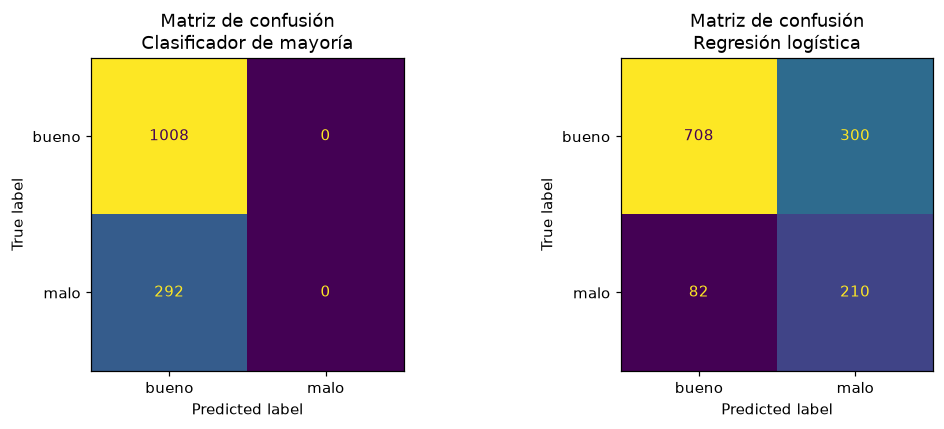

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, titulo in [(axes[0], pred_mayoria, "Clasificador de mayoría"),
                         (axes[1], pred_logreg, "Regresión logística")]:
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=["bueno", "malo"],
                                            ax=ax, colorbar=False)
    ax.set_title(f"Matriz de confusión\n{titulo}")
fig.tight_layout()
plt.show()

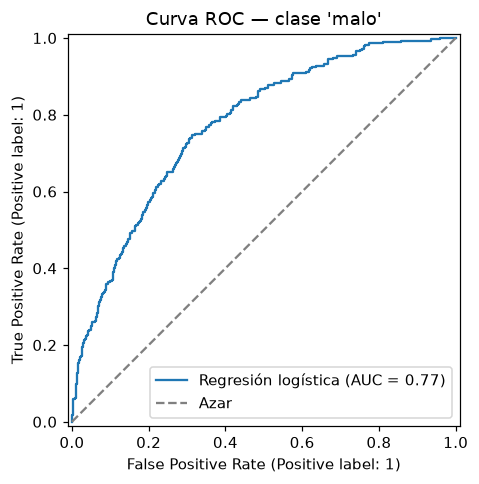

In [10]:
fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(
    (y_test == CLASE_POSITIVA).astype(int), proba_logreg, name="Regresión logística", ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — clase 'malo'")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Resumen comparativo de las líneas base

Armamos esta tabla resumen, aunque ya imprimimos los reportes completos, porque
los notebooks de modelamiento avanzado van a comparar sus métricas contra estas
dos líneas base, y tener los números clave juntos hace esa comparación más
directa. El costo esperado usa la matriz de costos del artículo (falso negativo
= 5, falso positivo = 1), promediado por cliente de test.

In [11]:
def costo_medio(y_true, y_pred, c_fn=5, c_fp=1):
    fn = ((y_true == "malo") & (y_pred == "bueno")).sum()
    fp = ((y_true == "bueno") & (y_pred == "malo")).sum()
    return (c_fn * fn + c_fp * fp) / len(y_true)

resumen = pd.DataFrame({
    "Clasificador de mayoría": [
        (pred_mayoria == y_test).mean(),
        recall_score(y_test, pred_mayoria, pos_label=CLASE_POSITIVA),
        f1_score(y_test, pred_mayoria, pos_label=CLASE_POSITIVA, zero_division=0),
        np.nan,
        costo_medio(y_test, pred_mayoria),
    ],
    "Regresión logística": [
        (pred_logreg == y_test).mean(),
        recall_score(y_test, pred_logreg, pos_label=CLASE_POSITIVA),
        f1_score(y_test, pred_logreg, pos_label=CLASE_POSITIVA),
        auc_logreg,
        costo_medio(y_test, pred_logreg),
    ],
}, index=["Accuracy", "Recall (malo)", "F1 (malo)", "ROC-AUC (malo)", "Costo medio (5:1)"])

resumen.round(3)

,Clasificador de mayoría,Regresión logística
Accuracy,0.775,0.706
Recall (malo),0.000,0.719
F1 (malo),0.000,0.524
ROC-AUC (malo),NaN,0.773
Costo medio (5:1),1.123,0.546


## 10. Conclusiones

- **Partición:** 80/20 estratificada con semilla 42: 5.200 registros de
  entrenamiento y 1.300 de prueba (292 "malos"), con la misma proporción de
  "malo" (22.5%) en ambas.
- **Flujo sin fuga:** imputación (saldo por categoría, mediana y moda),
  escalamiento, balanceo opcional con `SMOTENC` y codificación one-hot, todo
  encapsulado en un `imblearn.Pipeline` (`src/preprocesamiento.py`) que se
  ajusta solo con `X_train`. Cualquier decisión de diseño se toma con validación
  cruzada dentro de train, nunca con test.
- **Balanceo:** `class_weight="balanced"` supera a `SMOTENC` en validación
  cruzada (ROC-AUC 0.765 frente a 0.750; recall de "malo" 0.695 frente a 0.632),
  así que es la estrategia recomendada para el resto de modelos.
- **Clasificador de mayoría:** 77.5% de accuracy pero 0% de recall sobre "malo"
  y un costo medio de 1.12 por cliente con la matriz 5:1, lo que confirma que la
  accuracy sola es una métrica inadecuada para este problema.
- **Regresión logística (con `class_weight`):** ROC-AUC de 0.773, recall de
  "malo" de 0.719 y costo medio de 0.55, menos de la mitad que el clasificador
  de mayoría. Esta es la referencia real que SVM y los demás modelos avanzados
  tienen que superar.